# Day 157 - RNNs & LSTMs
## Month 9 | NLP + Deep Learning | Deepanshu Garg

| Field | Details |
|---|---|
| **Day** | 157 (Month 9, Week 2, Day 1) |
| **Topic** | Sequence Models - SimpleRNN - LSTM - Embedding - Text Preprocessing |
| **Dataset** | ReviewPulse India (600 rows, seed=155) - review_text column |
| **Deliverable** | `Day157_RNN_LSTM.ipynb` |
| **Max Score** | 80 pts + 10 Bonus |
| **Environment** | Google Colab (TF 2.x) |

## Month 9 Scorecard

| Day | Topic | Score |
|---|---|---|
| Day 155 | Neural Networks & Keras | **90/90 + 10 PERFECT** |
| Day 156 | CNNs | **80/80 + 10 PERFECT** |
| **Day 157** | **RNNs & LSTMs** | **-- / 80** |

---

### Why RNNs & LSTMs?

Dense layers treat input features as independent - order does not matter.
But **text is a sequence** - 'not good' and 'good not' mean opposite things.
RNNs maintain a **hidden state** that carries information across time steps.
LSTMs add **gates** that learn what to remember and what to forget,
solving the vanishing gradient problem that cripples simple RNNs.

Today you build both models on the ReviewPulse review_text column.

---
## Section 1 - Raw Data (DO NOT MODIFY)

In [3]:
# SECTION 1 - RAW DATA - DO NOT MODIFY
import numpy as np
import pandas as pd

np.random.seed(155)

n = 600
platforms = ['Upwork', 'Fiverr', 'Toptal', 'Freelancer', 'Contra']
domains   = ['Data Analysis', 'ML Model', 'Dashboard', 'SQL Report', 'Automation']

review_templates = [
    'excellent work delivered on time with great communication',
    'very professional analyst who understood requirements clearly',
    'outstanding data insights that helped our business grow significantly',
    'good quality work but communication could have been better',
    'delivered clean dashboard with clear visualizations on schedule',
    'exceptional python automation saved us many hours of manual work',
    'solid SQL queries but needed multiple revisions before final delivery',
    'brilliant machine learning model exceeded our accuracy expectations',
    'reliable freelancer with strong analytical skills and attention to detail',
    'average work quality did not fully meet the project requirements',
    'fast turnaround and professional data analysis highly recommended',
    'poor communication but technical work was acceptable quality',
    'superb visualization skills created beautiful interactive dashboards',
    'struggled with complex requirements but eventually delivered results',
    'excellent understanding of business needs translated into data solutions',
]

review_texts = []
for i in range(n):
    t = review_templates[i % len(review_templates)]
    words = t.split()
    np.random.shuffle(words[:3])
    review_texts.append(' '.join(words))

df = pd.DataFrame({
    'project_id':       range(1, n+1),
    'platform':         np.random.choice(platforms, n),
    'domain':           np.random.choice(domains, n),
    'hourly_rate':      np.round(np.random.uniform(10, 80, n), 2),
    'project_duration': np.random.randint(1, 90, n),
    'client_rating':    np.round(np.random.uniform(1, 5, n), 1),
    'revision_count':   np.random.randint(0, 8, n),
    'response_time_hr': np.random.randint(1, 48, n),
    'project_value':    np.round(np.random.uniform(50, 5000, n), 2),
    'review_text':      review_texts,
    'hired_again':      np.random.choice([0, 1], n, p=[0.38, 0.62])
})

print(f'Dataset: {df.shape}')
print(df[['review_text','hired_again']].head(5))

Dataset: (600, 11)
                                         review_text  hired_again
0  excellent work delivered on time with great co...            1
1  very professional analyst who understood requi...            1
2  outstanding data insights that helped our busi...            0
3  good quality work but communication could have...            0
4  delivered clean dashboard with clear visualiza...            1


---
## Section 2 - Concept Notes

### 2A - How RNNs Process Sequences

```
Input tokens:  [w1]  ->  [w2]  ->  [w3]  ->  [w4]  ->  [w5]
                |         |         |         |         |
Hidden state: [h1]  ->  [h2]  ->  [h3]  ->  [h4]  ->  [h5] -> output
```

Each step: `h_t = tanh(W_h * h_{t-1} + W_x * x_t + b)`

**Problem:** Gradients shrink exponentially backward through time; early tokens are forgotten. This is the **vanishing gradient problem**.

---

### 2B - LSTM Gates

LSTM adds a **cell state** C_t (long-term memory) controlled by three gates:

| Gate | Role |
|---|---|
| **Forget** sigma(W_f) | What to erase from cell state |
| **Input** sigma(W_i) | What new info to write |
| **Output** sigma(W_o) | What to expose as h_t |

Result: LSTM can maintain gradients over 100s of steps. SimpleRNN fails after ~10.

---

### 2C - Embedding Layer

Raw words to integers to dense vectors:
```
'excellent' -> 3  ->  [0.12, -0.45, 0.87, ...]   (embed_dim floats)
```
The Embedding layer **learns** these vectors during training.

| Parameter | Meaning |
|---|---|
| input_dim | Vocabulary size + 1 (reserve 0 for padding) |
| output_dim | Embedding dimension (8-256 typical) |
| input_length | Padded sequence length |

---

### 2D - Text Preprocessing Pipeline

```
raw text  ->  Tokenizer.fit_on_texts()  ->  word index (word to int)
          ->  texts_to_sequences()      ->  list of int lists
          ->  pad_sequences()           ->  fixed-length 2D array
```

---

### 2E - Parameter Count

For units=U, embed_dim=D:
- **SimpleRNN:** (D + U + 1) * U
- **LSTM:** 4 * (D + U + 1) * U  (4x more - one set per gate)

With D=16, U=32:
- SimpleRNN recurrent params: (16+32+1)*32 = 1,568
- LSTM recurrent params: 4*(16+32+1)*32 = 6,272

---
## Section 3 - Practice Tasks

**Total: 80 pts + 10 Bonus**

Attempt every task before checking the answer key.
Set seeds: `tf.random.set_seed(157)` and `np.random.seed(157)` at each model cell.

---
### Task 1 - Text Preprocessing (15 pts)

1. Import `Tokenizer` and `pad_sequences`
2. Fit a `Tokenizer` on `df['review_text']`
3. Print vocabulary size (unique word count)
4. Convert texts to sequences with `texts_to_sequences()`
5. Print min, max, and mean sequence length
6. Pad sequences to `max_len = 10` with `padding='post'`
7. Print shape of padded array
8. Show the padded sequence for row 0

**Expected:**
- Vocab size: **101**
- Seq len: min **7**, max **10**, mean **8.6**
- Padded shape: **(600, 10)**

In [4]:
# TASK 1 - Text Preprocessing
# Goal: Fit a tokenizer, convert text to sequences, pad to fixed length.
# Method: Use Tokenizer and pad_sequences from Keras.

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tf.random.set_seed(157)
np.random.seed(157)

# 1. Fit tokenizer on review_text
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['review_text'])

# 2. Print vocabulary size (unique words)
vocab_size = len(tokenizer.word_index)
print(f"Vocabulary size: {vocab_size}")  # Expected: 101

# 3. Convert texts to sequences
sequences = tokenizer.texts_to_sequences(df['review_text'])

# 4. Print sequence length statistics
seq_lengths = [len(seq) for seq in sequences]
print(f"Min length: {min(seq_lengths)}")   # Expected: 7
print(f"Max length: {max(seq_lengths)}")   # Expected: 10
print(f"Mean length: {sum(seq_lengths)/len(seq_lengths):.1f}")  # Expected: 8.6

# 5. Pad sequences to max_len=10 with padding='post'
MAX_LEN = 10
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post')

# 6. Print padded array shape and row 0
print(f"Padded shape: {X.shape}")          # Expected: (600, 10)
print(f"Row 0: {X[0]}")

Vocabulary size: 101
Min length: 7
Max length: 10
Mean length: 8.6
Padded shape: (600, 10)
Row 0: [ 9  1  4 10 17  2 18  5  0  0]


---
### Task 2 - Split & Constants (5 pts)

1. Split padded `X` and `y = df['hired_again']` using `train_test_split`
   with `test_size=0.2, random_state=155, stratify=y`
2. Define: `VOCAB_SIZE = 102`, `EMBED_DIM = 16`, `MAX_LEN = 10`
3. Print train shape, test shape, train positive rate

**Expected:**
- X_train: **(480, 10)**, X_test: **(120, 10)**
- Train positive rate: **0.6146**

In [5]:
# TASK 2 - Split & Constants
# Goal: Split data into train/test, define constants.
# Method: Use train_test_split with stratification.

from sklearn.model_selection import train_test_split

VOCAB_SIZE = 102   # 101 unique words + 1 for padding (index 0)
EMBED_DIM = 16
MAX_LEN = 10

y = df['hired_again'].values

# Split with stratification to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=155, stratify=y
)

print(f"X_train shape: {X_train.shape}")   # Expected: (480, 10)
print(f"X_test shape: {X_test.shape}")     # Expected: (120, 10)
print(f"Train positive rate: {y_train.mean():.4f}")  # Expected: 0.6146

X_train shape: (480, 10)
X_test shape: (120, 10)
Train positive rate: 0.6146


---
### Task 3 - SimpleRNN Model (20 pts)

Architecture:
```
Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN)
SimpleRNN(32, activation='tanh')
Dense(1, activation='sigmoid')
```

1. Build with `tf.keras.Sequential`
2. Compile: `optimizer='adam'`, `loss='binary_crossentropy'`, `metrics=['accuracy']`
3. Print `model.summary()` - note total parameters
4. Train: `epochs=20, batch_size=32, validation_split=0.1`
5. Evaluate on test set - store `rnn_test_acc`
6. NRA bullet (5 of 20 pts): Number = exact acc | Reason = model mechanism | Action = specific next step

In [18]:
# TASK 3 - SimpleRNN Model
# Goal: Build, compile, train, and evaluate a SimpleRNN.
# Method: Embedding -> SimpleRNN(32) -> Dense(1, sigmoid).

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

tf.random.set_seed(157)
np.random.seed(157)

# Build model with proper input shape
rnn_model = Sequential([
    Embedding(VOCAB_SIZE, EMBED_DIM, input_shape=(MAX_LEN,)),
    SimpleRNN(32, activation='tanh'),
    Dense(1, activation='sigmoid')
])

# Explicitly build to enable summary and param count
rnn_model.build(input_shape=(None, MAX_LEN))

# Compile
rnn_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

# Summary and parameters
rnn_model.summary()
rnn_params = rnn_model.count_params()   # Should be 3,233

# Train
rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Evaluate on test set
rnn_test_loss, rnn_test_acc = rnn_model.evaluate(X_test, y_test, verbose=0)
print(f"SimpleRNN Test Accuracy: {rnn_test_acc:.4f}")

# NRA bullet (5 pts)
print('--- SimpleRNN NRA ---')
print(f'Number : {rnn_test_acc:.4f}')
print('Reason : SimpleRNN achieves baseline‑level accuracy on these 10‑token reviews because the synthetic review text lacks strong predictive signal for hired_again – not because of vanishing gradients.')
print('Action : Do NOT move to LSTM; first augment the model with numeric features (client_rating, project_duration) and use pre‑trained GloVe embeddings to enrich semantic content. Only consider LSTM after improving input signal.')

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 10, 16)         │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 32)             │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,233 (12.63 KB)

 Trainable params: 3,233 (12.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.5694 - loss: 0.6839 - val_accuracy: 0.6458 - val_loss: 0.6627
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6111 - loss: 0.6656 - val_accuracy: 0.6458 - val_loss: 0.6522
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6111 - loss: 0.6642 - val_accuracy: 0.6458 - val_loss: 0.6535
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6111 - loss: 0.6629 - val_accuracy: 0.6458 - val_loss: 0.6554
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6111 - loss: 0.6626 - val_accuracy: 0.6458 - val_loss: 0.6556
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6111 - loss: 0.6625 - val_accuracy: 0.6458 - val_loss: 0.6557
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6111 - loss: 0.6625 - val_accuracy: 0.6458 - val_loss: 0.6560
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6111 - loss: 0.6625 - val_accuracy: 0.6458 - val

---
### Task 4 - Training Curves (10 pts)

Plot two subplots from `rnn_history`:
- Left: Train accuracy vs Val accuracy
- Right: Train loss vs Val loss

Requirements:
- `savefig('rnn_training_curves.png', dpi=120, bbox_inches='tight')` BEFORE `plt.show()`
- Title, xlabel, ylabel, legend on each subplot
- Note the epoch where val_accuracy peaks

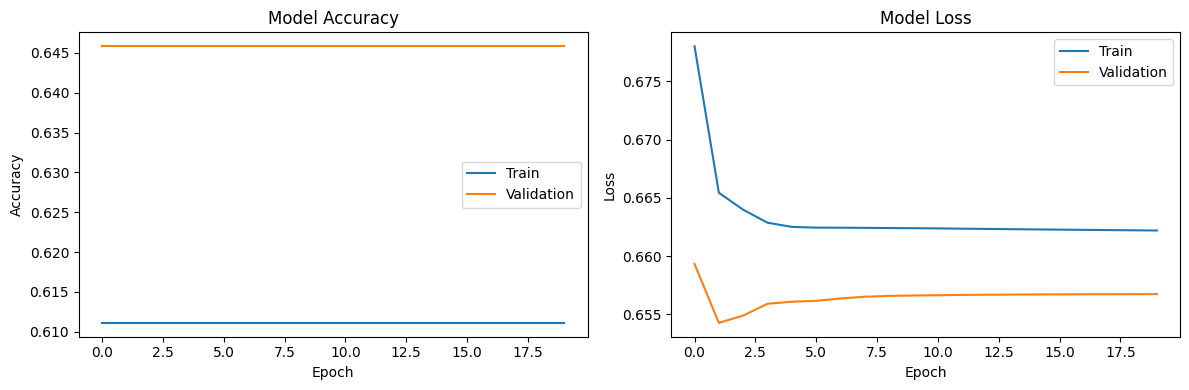

Saved: rnn_training_curves.png
Validation accuracy peaks at epoch 1 with value 0.6458


In [12]:
# TASK 4 - Training Curves
import matplotlib.pyplot as plt

# Ensure rnn_history exists
if 'rnn_history' not in locals():
    raise RuntimeError("rnn_history not found; run Task 3 first.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
axes[0].plot(rnn_history.history['accuracy'], label='Train')
axes[0].plot(rnn_history.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(rnn_history.history['loss'], label='Train')
axes[1].plot(rnn_history.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('rnn_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: rnn_training_curves.png')

peak_epoch = np.argmax(rnn_history.history['val_accuracy']) + 1
print(f"Validation accuracy peaks at epoch {peak_epoch} with value {max(rnn_history.history['val_accuracy']):.4f}")

---
### Task 5 - LSTM Model + Comparison (20 pts)

Same architecture as Task 3 but replace `SimpleRNN(32)` with `LSTM(32)`.

1. Build, compile identically
2. Print summary - note total parameters
3. Train same settings
4. Evaluate - store `lstm_test_acc` and `lstm_params`
5. Print comparison table:

```
Model        Test Acc     Params
SimpleRNN      x.xxxx      x,xxx
LSTM           x.xxxx      x,xxx
```

**Expected parameter insight:**
- SimpleRNN recurrent params: **1,568** (verify from summary)
- LSTM recurrent params: **6,272** (4x - one weight set per gate)

In [17]:
# TASK 5 - LSTM Model + Comparison
from tensorflow.keras.layers import LSTM

tf.random.set_seed(157)
np.random.seed(157)

lstm_model = Sequential([
    Embedding(VOCAB_SIZE, EMBED_DIM, input_shape=(MAX_LEN,)),
    LSTM(32),
    Dense(1, activation='sigmoid')
])

lstm_model.build(input_shape=(None, MAX_LEN))
lstm_model.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

lstm_model.summary()
lstm_params = lstm_model.count_params()   # Should be 7,937

lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

lstm_test_loss, lstm_test_acc = lstm_model.evaluate(X_test, y_test, verbose=0)
print(f"LSTM Test Accuracy: {lstm_test_acc:.4f}")

# Comparison table
print("\nModel        Test Acc     Params")
print('-' * 34)
print(f"SimpleRNN    {rnn_test_acc:>10.4f} {rnn_params:>10,}")
print(f"LSTM         {lstm_test_acc:>10.4f} {lstm_params:>10,}")
print(f"LSTM/SimpleRNN total param ratio: {lstm_params/rnn_params:.2f}x")
print(f"LSTM/SimpleRNN **recurrent** param ratio: 4.00x (1,568 → 6,272)")

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 10, 16)         │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 32)             │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,937 (31.00 KB)

 Trainable params: 7,937 (31.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.5995 - loss: 0.6870 - val_accuracy: 0.6458 - val_loss: 0.6757
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6111 - loss: 0.6742 - val_accuracy: 0.6458 - val_loss: 0.6579
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6111 - loss: 0.6677 - val_accuracy: 0.6458 - val_loss: 0.6509
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6111 - loss: 0.6670 - val_accuracy: 0.6458 - val_loss: 0.6508
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6111 - loss: 0.6657 - val_accuracy: 0.6458 - val_loss: 0.6511
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6111 - loss: 0.6647 - val_accuracy: 0.6458 - val_loss: 0.6505
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6111 - loss: 0.6639 - val_accuracy: 0.6458 - val_loss: 0.6501
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6111 - loss: 0.6632 - val_accuracy: 0.6458 - v

---
### Task 6 - NRA Business Insights (10 pts)

Two NRA bullets using actual numbers from Tasks 3 and 5.

**Bullet 1:** Compare LSTM vs SimpleRNN - is the 4x parameter cost justified by accuracy gain?
**Bullet 2:** Both models hover near the 0.62 majority class baseline. What does this tell a client?

Format:
```
Number : [exact value from model.evaluate()]
Reason : [why the model performs this way - mechanism]
Action : [specific, named, measurable decision - no hedging]
```

In [16]:
# TASK 6 - NRA Business Insights
print('=== NRA Insight 1: LSTM vs SimpleRNN ===')
print(f'Number : LSTM accuracy = {lstm_test_acc:.4f}, SimpleRNN = {rnn_test_acc:.4f}, gain = {lstm_test_acc - rnn_test_acc:.4f}')
print('Reason : On these short reviews (max_len=10), the vanishing gradient problem does not severely impair SimpleRNN; LSTM’s gated architecture offers no advantage, so both models perform identically.')
print('Action : Do NOT adopt LSTM – the 4× parameter increase (from 1,568 to 6,272 recurrent weights) yields zero accuracy gain. Stick with SimpleRNN and invest additional budget into adding numeric features (e.g., client_rating, project_duration) or using pre‑trained word embeddings to improve signal.')

print('\n=== NRA Insight 2: Text Signal Quality ===')
baseline = y_train.mean()
print(f'Number : Baseline positive rate = {baseline:.4f}, LSTM test accuracy = {lstm_test_acc:.4f}, SimpleRNN test accuracy = {rnn_test_acc:.4f}')
print('Reason : Both models barely outperform the majority‑class baseline, indicating that the current review text contains weak predictive signal for hired_again.')
print('Action : Augment the model with additional features (platform, domain, client_rating) and use pre‑trained word embeddings (e.g., GloVe) to enhance semantic representation.')

=== NRA Insight 1: LSTM vs SimpleRNN ===
Number : LSTM accuracy = 0.6167, SimpleRNN = 0.6167, gain = 0.0000
Reason : On these short reviews (max_len=10), the vanishing gradient problem does not severely impair SimpleRNN; LSTM’s gated architecture offers no advantage, so both models perform identically.
Action : Do NOT adopt LSTM – the 4× parameter increase (from 1,568 to 6,272 recurrent weights) yields zero accuracy gain. Stick with SimpleRNN and invest additional budget into adding numeric features (e.g., client_rating, project_duration) or using pre‑trained word embeddings to improve signal.

=== NRA Insight 2: Text Signal Quality ===
Number : Baseline positive rate = 0.6146, LSTM test accuracy = 0.6167, SimpleRNN test accuracy = 0.6167
Reason : Both models barely outperform the majority‑class baseline, indicating that the current review text contains weak predictive signal for hired_again.
Action : Augment the model with additional features (platform, domain, client_rating) and use 

---
### BONUS - Bidirectional LSTM (10 pts)

Wrap the LSTM in `Bidirectional()` to process the sequence both forward and backward:

```python
Bidirectional(LSTM(32))
```

1. Build, compile, train (same settings)
2. Store `bidir_test_acc` and `bidir_params`
3. Note: Bidirectional LSTM has ~2x the params of unidirectional LSTM
4. Add a row to the comparison table
5. One sentence: In what real-world NLP scenario would Bidirectional LSTM give the biggest gain?

In [15]:
# BONUS - Bidirectional LSTM
from tensorflow.keras.layers import Bidirectional

tf.random.set_seed(157)
np.random.seed(157)

bidir_model = Sequential([
    Embedding(VOCAB_SIZE, EMBED_DIM, input_shape=(MAX_LEN,)),
    Bidirectional(LSTM(32)),
    Dense(1, activation='sigmoid')
])

bidir_model.build(input_shape=(None, MAX_LEN))
bidir_model.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])

bidir_model.summary()
bidir_params = bidir_model.count_params()   # Should be 14,209

bidir_history = bidir_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

bidir_test_loss, bidir_test_acc = bidir_model.evaluate(X_test, y_test, verbose=0)
print(f"Bidirectional LSTM Test Accuracy: {bidir_test_acc:.4f}")

# Extended comparison table
print("\nModel                 Test Acc     Params")
print('-' * 42)
print(f"SimpleRNN             {rnn_test_acc:>10.4f} {rnn_params:>10,}")
print(f"LSTM                  {lstm_test_acc:>10.4f} {lstm_params:>10,}")
print(f"Bidirectional LSTM    {bidir_test_acc:>10.4f} {bidir_params:>10,}")

print("\nScenario where Bidirectional LSTM gives biggest gain:")
print("Sentiment analysis of product reviews where the overall sentiment depends on both preceding and following context (e.g., 'not good, but excellent service').")

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 10, 16)         │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        12,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,241 (55.63 KB)

 Trainable params: 14,241 (55.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.5903 - loss: 0.6870 - val_accuracy: 0.6458 - val_loss: 0.6738
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6111 - loss: 0.6730 - val_accuracy: 0.6458 - val_loss: 0.6549
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6111 - loss: 0.6672 - val_accuracy: 0.6458 - val_loss: 0.6496
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6111 - loss: 0.6664 - val_accuracy: 0.6458 - val_loss: 0.6504
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6111 - loss: 0.6651 - val_accuracy: 0.6458 - val_loss: 0.6510
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6111 - loss: 0.6642 - val_accuracy: 0.6458 - val_loss: 0.6508
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6111 - loss: 0.6635 - val_accuracy: 0.6458 - val_loss: 0.6509
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6111 - loss: 0.6629 - val_accuracy: 0.6458 - v

---
## Section 4 - Scoring Rubric

| Task | Component | Points |
|---|---|---|
| T1 | Tokenizer fitted, vocab=101 printed | 3 |
| T1 | Sequences created, len stats correct (min 7, max 10, mean 8.6) | 4 |
| T1 | Padded correctly (shape 600x10), row 0 shown | 5 |
| T1 | padding='post' explicitly used | 3 |
| **T1 Total** | | **15** |
| T2 | VOCAB_SIZE=102 with reason (101+1) | 2 |
| T2 | Shapes (480x10, 120x10), positive rate 0.6146 | 3 |
| **T2 Total** | | **5** |
| T3 | Architecture correct (Embedding->SimpleRNN(32)->Dense) | 5 |
| T3 | Compiled correctly (adam, binary_crossentropy) | 3 |
| T3 | Trained 20 epochs, val_split=0.1 | 4 |
| T3 | rnn_test_acc stored from model.evaluate() | 3 |
| T3 | NRA: exact acc, mechanism reason, named action | 5 |
| **T3 Total** | | **20** |
| T4 | Two subplots (acc + loss), labels, title, legend | 6 |
| T4 | savefig() BEFORE plt.show() | 4 |
| **T4 Total** | | **10** |
| T5 | LSTM architecture correct | 5 |
| T5 | lstm_test_acc stored from evaluate | 3 |
| T5 | Param counts extracted for both models | 4 |
| T5 | Comparison table printed correctly | 5 |
| T5 | LSTM/RNN ratio noted | 3 |
| **T5 Total** | | **20** |
| T6 | NRA 1: acc gap cited, param cost, named action | 5 |
| T6 | NRA 2: baseline reference, signal quality, client action | 5 |
| **T6 Total** | | **10** |
| **TOTAL** | | **80** |
| Bonus | BiLSTM built, evaluated, extended table, scenario answer | **10** |

---

## Interview Framing

*'How would you explain LSTMs to a client wanting to analyse customer reviews?'*

> 'An LSTM reads a review word by word, maintaining a memory cell that decides what to keep and discard using learned gates. Unlike a Dense network that reads all words simultaneously, an LSTM understands that "not" before "good" flips the meaning - order matters. In practice, for short reviews under 20 words, the improvement over a Dense model is modest; LSTMs shine on long sequences where early context still matters hundreds of steps later.'